# Init

In [2]:
%cd ..

/usr2/zihaoye/TabFT


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import cycle

def _conditional_expectation(x: np.ndarray, y_bin: np.ndarray):
    order = np.argsort(x)
    x_sorted, y_sorted = x[order], y_bin[order]
    unique_x, idx = np.unique(x_sorted, return_inverse=True)

    sum_y  = np.bincount(idx, weights=y_sorted, minlength=unique_x.size)
    cnt_y  = np.bincount(idx, minlength=unique_x.size).astype(float)
    mu     = np.divide(sum_y, cnt_y, out=np.zeros_like(sum_y), where=cnt_y > 0)
    return unique_x, mu


def _compute_optimal_T(x: np.ndarray, y: np.ndarray):
    order = np.argsort(x)
    x_sorted, y_sorted = x[order], y[order]
    delta_y = np.diff(y_sorted)
    TV = np.sum(np.abs(delta_y))
    return TV


def analyze_relative_slopes(
        X: np.ndarray,
        y: np.ndarray,
        is_regression: bool = False):
    n, d = X.shape
    class_list = np.unique(y) if not is_regression else [None]

    summary_records, all_relative_slopes = [], []
    feature_relative_slopes, cond_exp = {}, {}

    for j in range(d):
        x = X[:, j].astype(float)

        if np.allclose(x.max(), x.min()):
            summary_records.append((j, 0., 0., 0.))
            feature_relative_slopes[j] = np.array([])
            cond_exp[j] = []
            continue

        x = (x - x.min()) / (x.max() - x.min())

        feature_slopes, feature_curves = [], []

        for c in class_list:
            y_bin = (y == c).astype(float) if c is not None else y.astype(float)
            if is_regression and c is None and y_bin.ptp() > 0:
                y_bin = (y_bin - y_bin.min()) / y_bin.ptp()

            u, mu = _conditional_expectation(x, y_bin)
            if len(u) <= 1:
                feature_curves.append((c, u, mu))   # still store for completeness
                continue

            mu_c = mu - mu.mean()
            feature_curves.append((c, u, mu_c))

            T_opt = _compute_optimal_T(u, mu_c)
            if T_opt == 0:
                continue

            slopes = np.diff(mu_c) / np.diff(u)
            rel_slopes = np.abs(slopes) / T_opt
            feature_slopes.extend(rel_slopes)

        feature_slopes = np.asarray(feature_slopes)
        feature_relative_slopes[j] = feature_slopes
        all_relative_slopes.extend(feature_slopes)
        cond_exp[j] = feature_curves

        max_s, min_s, mean_s = (feature_slopes.max(),
                                feature_slopes.min(),
                                feature_slopes.mean()) if feature_slopes.size else (0., 0., 0.)
        summary_records.append((j, max_s, min_s, mean_s))

    summary_df = (pd.DataFrame(summary_records,
                               columns=['feature', 'max_relative_slope',
                                        'min_relative_slope', 'mean_relative_slope'])
                    .set_index('feature'))

    return dict(summary=summary_df,
                relative_slopes=feature_relative_slopes,
                all_relative_slopes=np.asarray(all_relative_slopes),
                cond_exp=cond_exp)


def plot_relative_slope_distribution(results: dict,
                                     feature_idx: int = None,
                                     bins: int = 50,
                                     figsize: tuple = (12, 4),
                                     class_label=None,
                                     show_conditional=True):
    import matplotlib.pyplot as plt


    if feature_idx is not None:
        slopes = results['relative_slopes'][feature_idx]
        if slopes.size == 0:
            print(f"Feature {feature_idx} has no relative slopes to plot.")
            return

        nrows = 2 if show_conditional else 1
        fig, axes = plt.subplots(nrows, 1, figsize=figsize)
        if isinstance(axes, np.ndarray):
            axes = axes.ravel().tolist()
        else:
            axes = [axes]

        ax_hist = axes[0]
        ax_hist.hist(slopes, bins=bins, density=True, alpha=0.7,
                     edgecolor='black', linewidth=0.5)
        ax_hist.axvline(slopes.max(),  c='red',   ls='--', label=f'Max {slopes.max():.3f}')
        ax_hist.axvline(slopes.min(),  c='blue',  ls='--', label=f'Min {slopes.min():.3f}')
        ax_hist.axvline(slopes.mean(), c='green', ls='--', label=f'Mean {slopes.mean():.3f}')
        ax_hist.set_xlabel('Relative slope')
        ax_hist.set_ylabel('Density')
        ax_hist.set_title(f'Relative-slope distribution | feature {feature_idx}')
        ax_hist.grid(alpha=0.3)
        ax_hist.legend()

        if show_conditional:
            ax_curve = axes[1]
            curves = results['cond_exp'].get(feature_idx, [])
            to_plot = curves if class_label is None \
                           else [c for c in curves if c[0] == class_label]

            if not to_plot:
                ax_curve.set_title('No curve available')
            else:
                for c, u, mu_c in to_plot:
                    lbl = f'class {c}' if c is not None else 'regression'
                    ax_curve.plot(u, mu_c, lw=2, label=lbl)

            ax_curve.set_xlabel('u (feature value)')
            ax_curve.set_ylabel(r'$\mu_c(u)$  (mean-centred)')
            ax_curve.set_title('Conditional expectation')
            ax_curve.grid(alpha=0.3)
            ax_curve.legend()

        plt.tight_layout()
        return fig


    all_slopes = results['all_relative_slopes']
    if all_slopes.size == 0:
        print("No relative slopes to plot.")
        return

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    ax1.hist(all_slopes, bins=bins, density=True, alpha=0.7,
             edgecolor='black', linewidth=0.5)
    ax1.axvline(all_slopes.max(), color='red',   ls='--', label=f'Max {all_slopes.max():.3f}')
    ax1.axvline(all_slopes.min(), color='blue',  ls='--', label=f'Min {all_slopes.min():.3f}')
    ax1.axvline(all_slopes.mean(),color='green', ls='--', label=f'Mean {all_slopes.mean():.3f}')
    ax1.set_xlabel('Relative slope')
    ax1.set_ylabel('Density')
    ax1.set_title('Overall relative-slope distribution')
    ax1.grid(alpha=0.3)
    ax1.legend()

    feature_data = [v for v in results['relative_slopes'].values() if v.size]
    labels = [f'F{j}' for j, v in results['relative_slopes'].items() if v.size]
    if feature_data:
        ax2.boxplot(feature_data, labels=labels, showfliers=False)
        ax2.set_xlabel('Feature')
        ax2.set_ylabel('Relative slope')
        ax2.set_title('Per-feature distribution')
        ax2.grid(alpha=0.3)
        plt.setp(ax2.get_xticklabels(), rotation=45)

    plt.tight_layout()
    return fig


def get_relative_slope_stats(results: dict, feature_idx: int = None):
    if feature_idx is not None:
        slopes = results['relative_slopes'][feature_idx]
        if len(slopes) == 0:
            return {'count': 0, 'mean': 0, 'std': 0, 'min': 0, 'max': 0}
        
        return {
            'count': len(slopes),
            'mean': slopes.mean(),
            'std': slopes.std(),
            'min': slopes.min(),
            'max': slopes.max(),
            'median': np.median(slopes),
            'q25': np.percentile(slopes, 25),
            'q75': np.percentile(slopes, 75)
        }
    else:
        stats_list = []
        for feature_idx, slopes in results['relative_slopes'].items():
            if len(slopes) == 0:
                stats_list.append([feature_idx, 0, 0, 0, 0, 0, 0, 0, 0])
            else:
                stats_list.append([
                    feature_idx,
                    len(slopes),
                    slopes.mean(),
                    slopes.std(),
                    slopes.min(),
                    slopes.max(),
                    np.median(slopes),
                    np.percentile(slopes, 25),
                    np.percentile(slopes, 75)
                ])
        
        return pd.DataFrame(stats_list, 
                           columns=['feature', 'count', 'mean', 'std', 'min', 'max', 'median', 'q25', 'q75'])

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10, CIFAR100, MNIST, FashionMNIST
import warnings
warnings.filterwarnings('ignore')

def download_and_process_cifar10(data_dir='./data', sample_size=None):
    print("Downloading CIFAR-10...")
    
    transform = transforms.Compose([transforms.ToTensor()])
    
    trainset = CIFAR10(root=data_dir, train=True, download=True, transform=transform)
    testset = CIFAR10(root=data_dir, train=False, download=True, transform=transform)
    
    X_train = trainset.data.reshape(-1, 32*32*3).astype(np.float32) / 255.0
    y_train = np.array(trainset.targets)
    
    X_test = testset.data.reshape(-1, 32*32*3).astype(np.float32) / 255.0
    y_test = np.array(testset.targets)
    
    X = np.vstack([X_train, X_test])
    y = np.hstack([y_train, y_test])
    
    if sample_size and sample_size < len(X):
        indices = np.random.choice(len(X), sample_size, replace=False)
        X = X[indices]
        y = y[indices]
    
    print(f"CIFAR-10 loaded: {X.shape[0]} samples, {X.shape[1]} features, {len(np.unique(y))} classes")
    return X, y, "CIFAR-10"


def download_and_process_cifar100(data_dir='./data', sample_size=None):
    print("Downloading CIFAR-100...")
    
    transform = transforms.Compose([transforms.ToTensor()])
    
    trainset = CIFAR100(root=data_dir, train=True, download=True, transform=transform)
    testset = CIFAR100(root=data_dir, train=False, download=True, transform=transform)
    
    X_train = trainset.data.reshape(-1, 32*32*3).astype(np.float32) / 255.0
    y_train = np.array(trainset.targets)
    
    X_test = testset.data.reshape(-1, 32*32*3).astype(np.float32) / 255.0
    y_test = np.array(testset.targets)
    
    X = np.vstack([X_train, X_test])
    y = np.hstack([y_train, y_test])
    
    if sample_size and sample_size < len(X):
        indices = np.random.choice(len(X), sample_size, replace=False)
        X = X[indices]
        y = y[indices]
    
    print(f"CIFAR-100 loaded: {X.shape[0]} samples, {X.shape[1]} features, {len(np.unique(y))} classes")
    return X, y, "CIFAR-100"


def download_and_process_mnist(data_dir='./data', sample_size=None):
    print("Downloading MNIST...")
    
    transform = transforms.Compose([transforms.ToTensor()])
    
    trainset = MNIST(root=data_dir, train=True, download=True, transform=transform)
    testset = MNIST(root=data_dir, train=False, download=True, transform=transform)
    
    X_train = trainset.data.numpy().reshape(-1, 28*28).astype(np.float32) / 255.0
    y_train = trainset.targets.numpy()
    
    X_test = testset.data.numpy().reshape(-1, 28*28).astype(np.float32) / 255.0
    y_test = testset.targets.numpy()
    
    X = np.vstack([X_train, X_test])
    y = np.hstack([y_train, y_test])
    
    if sample_size and sample_size < len(X):
        indices = np.random.choice(len(X), sample_size, replace=False)
        X = X[indices]
        y = y[indices]
    
    print(f"MNIST loaded: {X.shape[0]} samples, {X.shape[1]} features, {len(np.unique(y))} classes")
    return X, y, "MNIST"


def download_and_process_fashion_mnist(data_dir='./data', sample_size=None):
    print("Downloading Fashion-MNIST...")
    
    transform = transforms.Compose([transforms.ToTensor()])
    
    trainset = FashionMNIST(root=data_dir, train=True, download=True, transform=transform)
    testset = FashionMNIST(root=data_dir, train=False, download=True, transform=transform)
    
    X_train = trainset.data.numpy().reshape(-1, 28*28).astype(np.float32) / 255.0
    y_train = trainset.targets.numpy()
    
    X_test = testset.data.numpy().reshape(-1, 28*28).astype(np.float32) / 255.0
    y_test = testset.targets.numpy()
    
    X = np.vstack([X_train, X_test])
    y = np.hstack([y_train, y_test])
    
    if sample_size and sample_size < len(X):
        indices = np.random.choice(len(X), sample_size, replace=False)
        X = X[indices]
        y = y[indices]
    
    print(f"Fashion-MNIST loaded: {X.shape[0]} samples, {X.shape[1]} features, {len(np.unique(y))} classes")
    return X, y, "Fashion-MNIST"


def download_and_process_olivetti_faces(sample_size=None):
    print("Downloading Olivetti Faces...")
    
    faces = fetch_olivetti_faces(shuffle=True, random_state=42)
    X = faces.data.astype(np.float32)  # 已经是[0,1]范围
    y = faces.target
    
    if sample_size and sample_size < len(X):
        indices = np.random.choice(len(X), sample_size, replace=False)
        X = X[indices]
        y = y[indices]
    
    print(f"Olivetti Faces loaded: {X.shape[0]} samples, {X.shape[1]} features, {len(np.unique(y))} classes")
    return X, y, "Olivetti Faces"


def analyze_multiple_datasets(datasets_config, sample_size=5000):
    all_results = {}
    summary_list = []
    
    for dataset_name, download_func in datasets_config:
        print(f"\n{'='*50}")
        print(f"Analyzing {dataset_name}")
        print(f"{'='*50}")
        
        try:
            # 下载和处理数据集
            if dataset_name == "Olivetti Faces":
                X, y, name = download_func(sample_size=sample_size)
            else:
                X, y, name = download_func(sample_size=sample_size)
            
            # 进行相对斜率分析
            print(f"Computing relative slope analysis...")
            results = analyze_relative_slopes(X, y, is_regression=False)
            
            # 保存结果
            all_results[name] = results
            
            # 收集摘要统计
            summary = results['summary']
            summary_stats = {
                'dataset': name,
                'n_samples': X.shape[0],
                'n_features': X.shape[1],
                'n_classes': len(np.unique(y)),
                'mean_max_slope': summary['max_relative_slope'].mean(),
                'mean_min_slope': summary['min_relative_slope'].mean(),
                'mean_mean_slope': summary['mean_relative_slope'].mean(),
                'std_max_slope': summary['max_relative_slope'].std(),
                'std_min_slope': summary['min_relative_slope'].std(),
                'std_mean_slope': summary['mean_relative_slope'].std(),
                'overall_max_slope': results['all_relative_slopes'].max() if len(results['all_relative_slopes']) > 0 else 0,
                'overall_min_slope': results['all_relative_slopes'].min() if len(results['all_relative_slopes']) > 0 else 0,
                'overall_mean_slope': results['all_relative_slopes'].mean() if len(results['all_relative_slopes']) > 0 else 0,
                'overall_std_slope': results['all_relative_slopes'].std() if len(results['all_relative_slopes']) > 0 else 0
            }
            summary_list.append(summary_stats)
            
            print(f"Analysis completed for {name}")
            print(f"Overall stats - Max: {summary_stats['overall_max_slope']:.3f}, "
                  f"Min: {summary_stats['overall_min_slope']:.3f}, "
                  f"Mean: {summary_stats['overall_mean_slope']:.3f}")
            
        except Exception as e:
            print(f"Error analyzing {dataset_name}: {str(e)}")
            continue
    
    # 创建汇总DataFrame
    summary_df = pd.DataFrame(summary_list)
    
    return all_results, summary_df


def plot_dataset_comparison(summary_df, figsize=(15, 10)):
    fig, axes = plt.subplots(2, 2, figsize=figsize)
    
    datasets = summary_df['dataset'].values
    
    ax1 = axes[0, 0]
    x = np.arange(len(datasets))
    width = 0.25
    
    ax1.bar(x - width, summary_df['overall_max_slope'], width, label='Max', alpha=0.8)
    ax1.bar(x, summary_df['overall_mean_slope'], width, label='Mean', alpha=0.8)
    ax1.bar(x + width, summary_df['overall_min_slope'], width, label='Min', alpha=0.8)
    
    ax1.set_xlabel('Dataset')
    ax1.set_ylabel('Relative Slope')
    ax1.set_title('Overall Relative Slope Statistics')
    ax1.set_xticks(x)
    ax1.set_xticklabels(datasets, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    ax2 = axes[0, 1]
    ax2.bar(x, summary_df['std_mean_slope'], alpha=0.8, color='orange')
    ax2.set_xlabel('Dataset')
    ax2.set_ylabel('Std of Mean Relative Slope')
    ax2.set_title('Variability Across Features')
    ax2.set_xticks(x)
    ax2.set_xticklabels(datasets, rotation=45, ha='right')
    ax2.grid(True, alpha=0.3)
    
    ax3 = axes[1, 0]
    ax3.scatter(summary_df['n_samples'], summary_df['overall_mean_slope'], 
               s=summary_df['n_features']/50, alpha=0.6, c=range(len(datasets)), cmap='viridis')
    ax3.set_xlabel('Number of Samples')
    ax3.set_ylabel('Overall Mean Relative Slope')
    ax3.set_title('Dataset Size vs Relative Slope')
    ax3.grid(True, alpha=0.3)
    
    for i, dataset in enumerate(datasets):
        ax3.annotate(dataset, (summary_df.iloc[i]['n_samples'], summary_df.iloc[i]['overall_mean_slope']),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    ax4 = axes[1, 1]
    ax4.scatter(summary_df['n_features'], summary_df['overall_mean_slope'], 
               s=summary_df['n_samples']/100, alpha=0.6, c=range(len(datasets)), cmap='plasma')
    ax4.set_xlabel('Number of Features')
    ax4.set_ylabel('Overall Mean Relative Slope')
    ax4.set_title('Feature Dimension vs Relative Slope')
    ax4.grid(True, alpha=0.3)
    
    for i, dataset in enumerate(datasets):
        ax4.annotate(dataset, (summary_df.iloc[i]['n_features'], summary_df.iloc[i]['overall_mean_slope']),
                    xytext=(5, 5), textcoords='offset points', fontsize=8)
    
    plt.tight_layout()
    return fig

def plot_dataset_feature(all_results: dict,
                         dataset_name: str,
                         feature_idx: int,
                         class_label=None,
                         show_conditional=True,
                         **kwargs):
    if dataset_name not in all_results:
        raise ValueError(f"'{dataset_name}' not found in all_results. "
                         f"Available: {list(all_results.keys())}")

    results = all_results[dataset_name]
    return plot_relative_slope_distribution(results,
                                            feature_idx=feature_idx,
                                            class_label=class_label,
                                            show_conditional=show_conditional,
                                            **kwargs)

# Overall Summary

In [8]:
datasets_config = [
        ("CIFAR-10", download_and_process_cifar10),
        ("CIFAR-100", download_and_process_cifar100),
        ("MNIST", download_and_process_mnist),
        ("Fashion-MNIST", download_and_process_fashion_mnist),
        ("Olivetti Faces", download_and_process_olivetti_faces),
    ]

In [9]:
all_results, summary_df = analyze_multiple_datasets(datasets_config, sample_size=5000)
    
print(f"\n{'='*60}")
print("SUMMARY OF ALL DATASETS")
print(f"{'='*60}")
print(summary_df.to_string(index=False))
 


Analyzing CIFAR-10
CIFAR-10 loaded: 5000 samples, 3072 features, 10 classes
Computing relative slope analysis...
Analysis completed for CIFAR-10
Overall stats - Max: 15.860, Min: 0.000, Mean: 1.000

Analyzing CIFAR-100
CIFAR-100 loaded: 5000 samples, 3072 features, 100 classes
Computing relative slope analysis...
Analysis completed for CIFAR-100
Overall stats - Max: 64.979, Min: 0.000, Mean: 1.000

Analyzing MNIST
MNIST loaded: 5000 samples, 784 features, 10 classes
Computing relative slope analysis...
Analysis completed for MNIST
Overall stats - Max: 255.000, Min: 0.000, Mean: 1.167

Analyzing Fashion-MNIST
Fashion-MNIST loaded: 5000 samples, 784 features, 10 classes
Computing relative slope analysis...
Analysis completed for Fashion-MNIST
Overall stats - Max: 255.000, Min: 0.000, Mean: 1.070

Analyzing Olivetti Faces
Olivetti Faces loaded: 400 samples, 4096 features, 40 classes
Computing relative slope analysis...
Analysis completed for Olivetti Faces
Overall stats - Max: 193.000, M

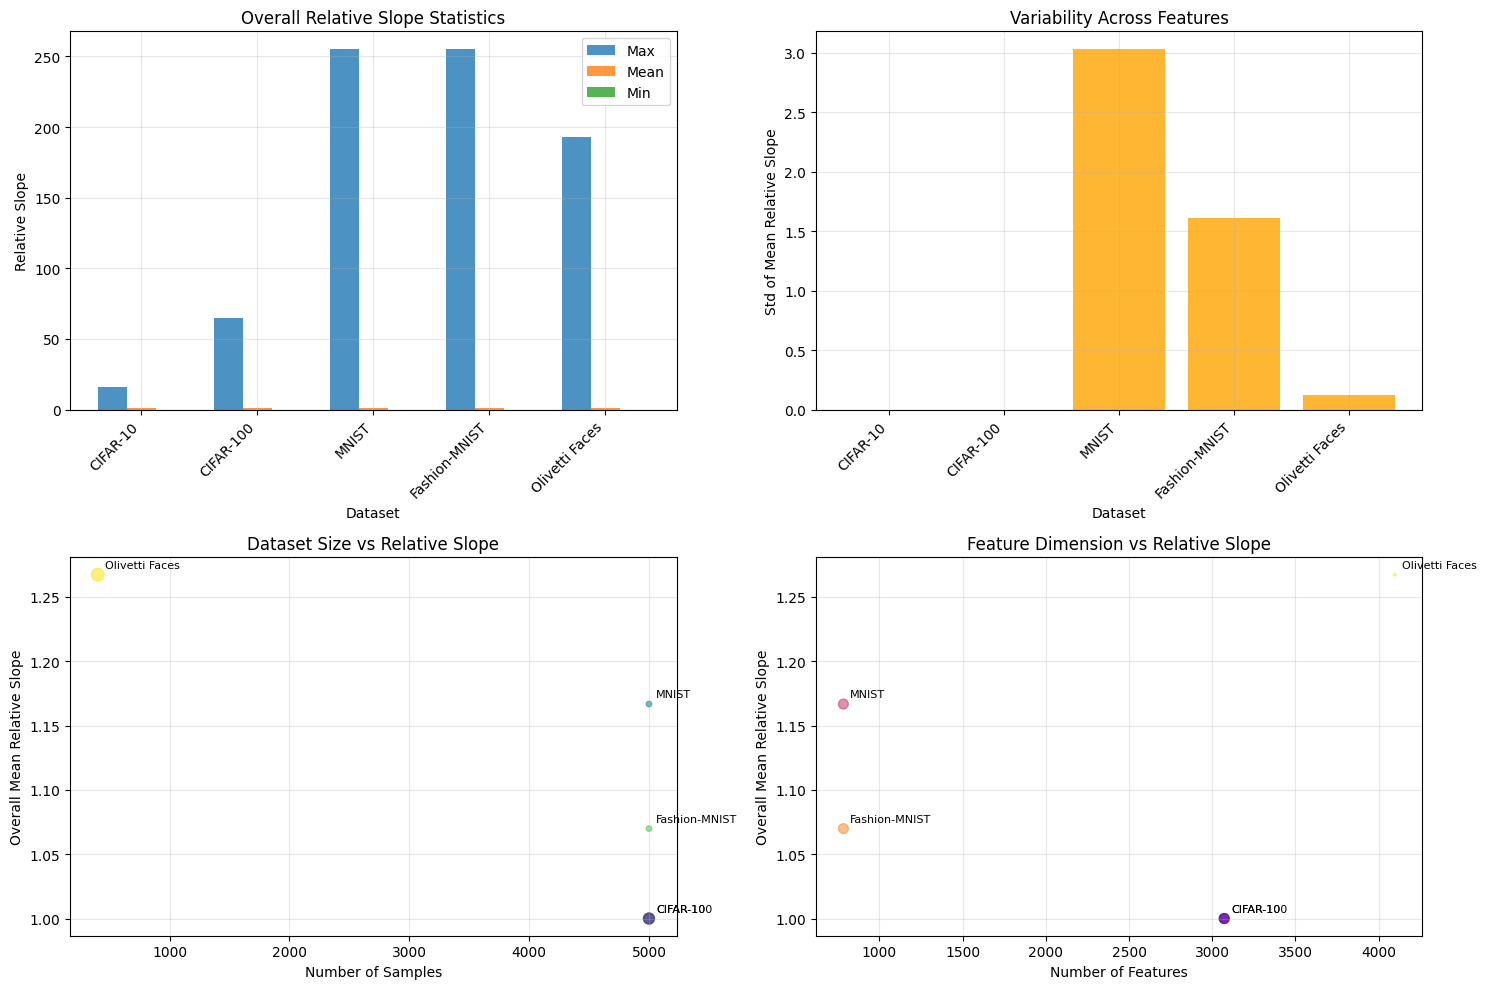


DETAILED DISTRIBUTION PLOTS

Plotting distribution for CIFAR-10...


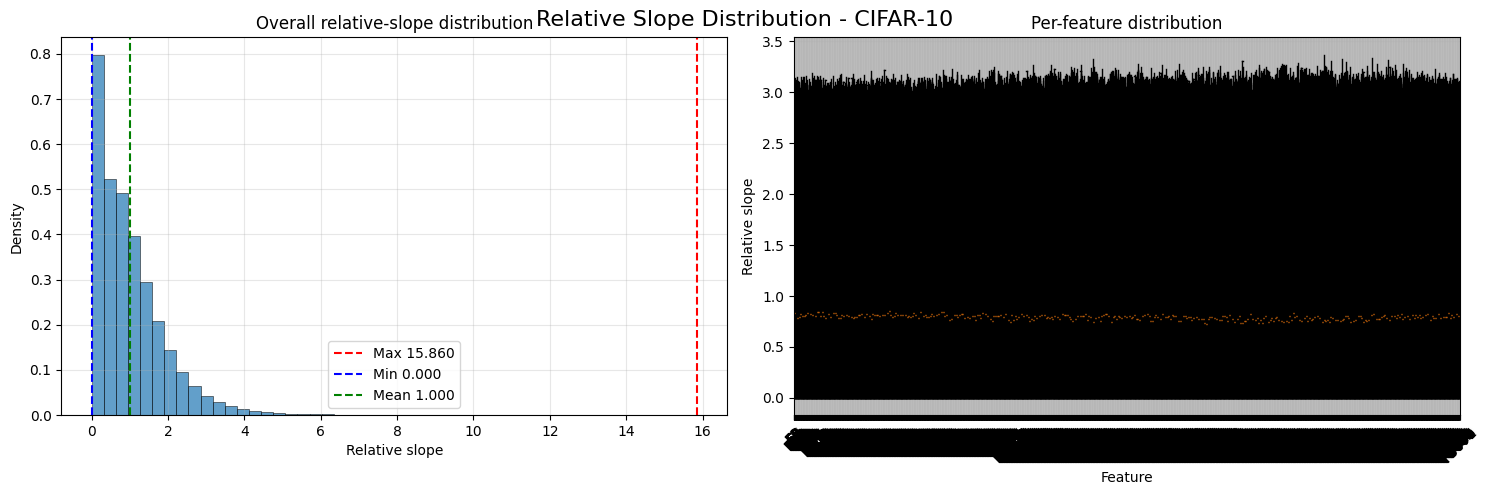


Plotting distribution for CIFAR-100...


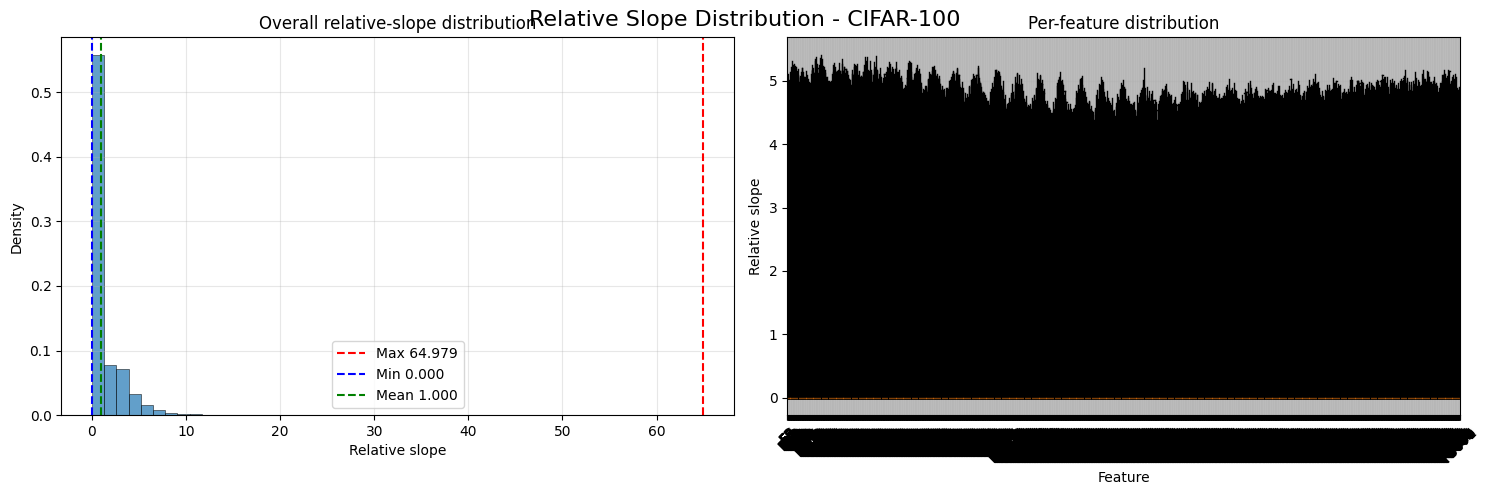


Plotting distribution for MNIST...


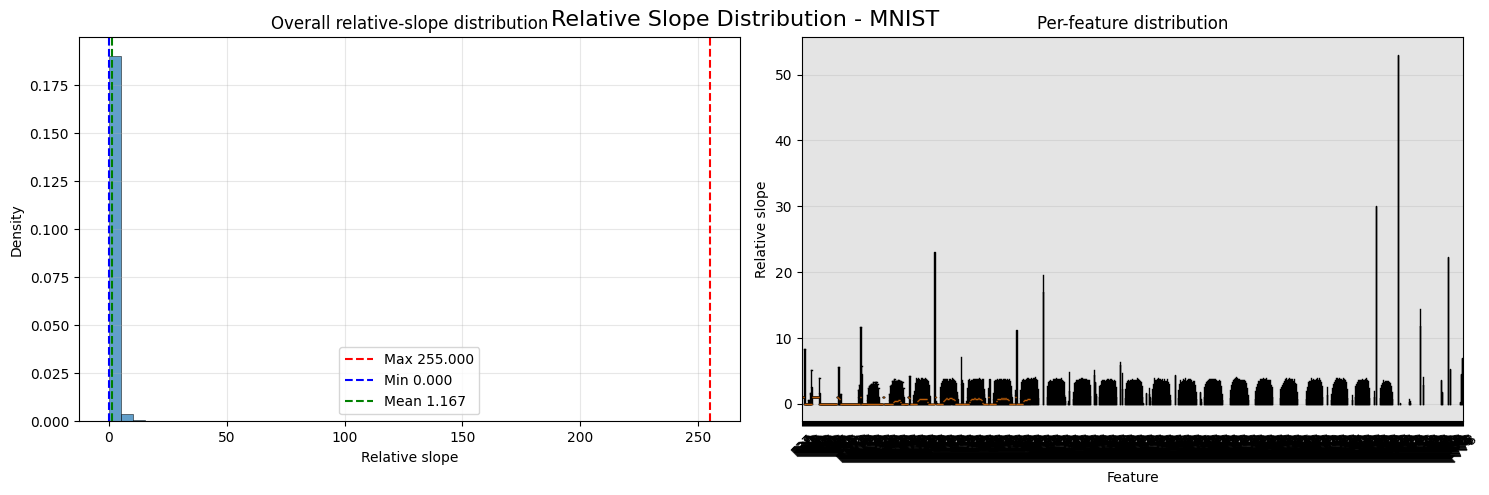


Plotting distribution for Fashion-MNIST...


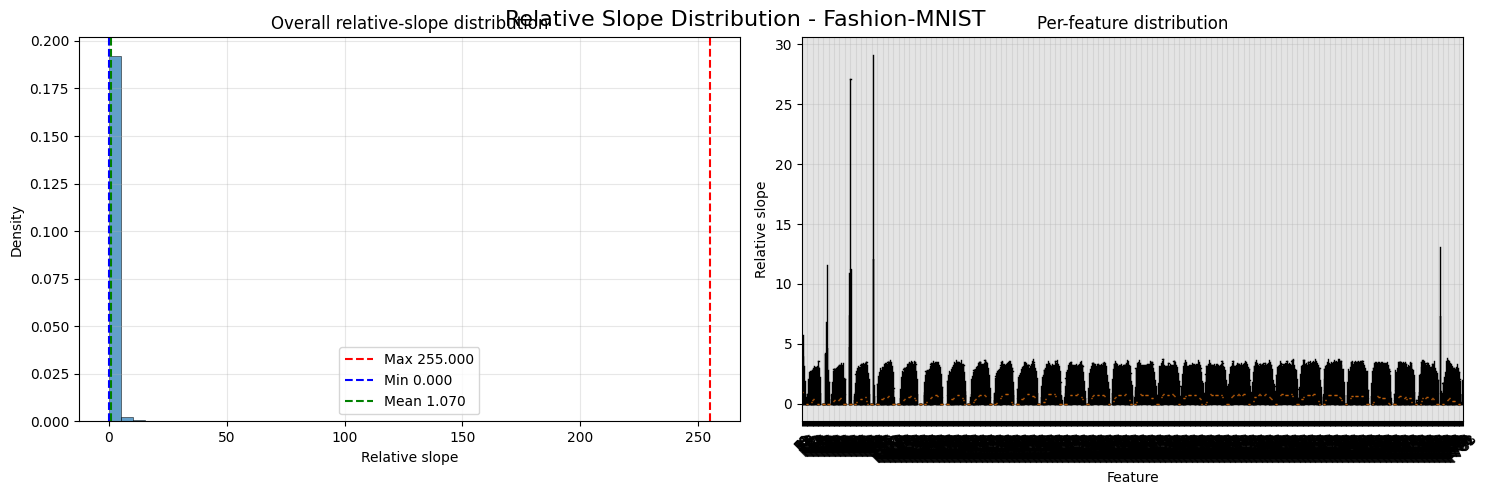


Plotting distribution for Olivetti Faces...


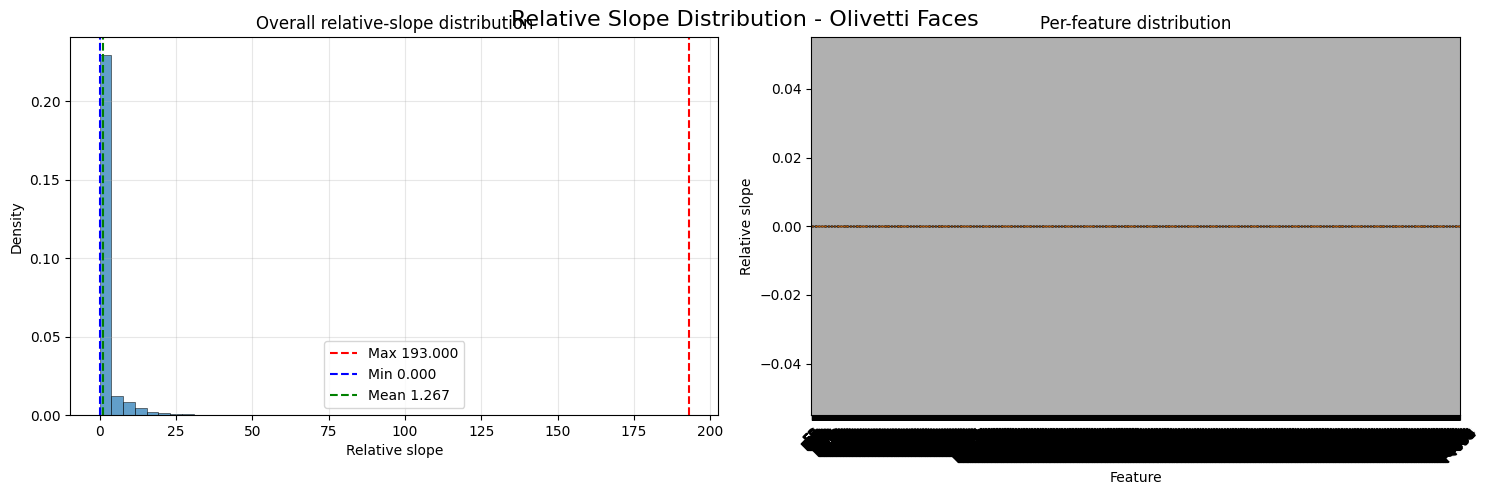

In [10]:
fig = plot_dataset_comparison(summary_df)
plt.show()

print(f"\n{'='*60}")
print("DETAILED DISTRIBUTION PLOTS")
print(f"{'='*60}")

for dataset_name, results in all_results.items():
    print(f"\nPlotting distribution for {dataset_name}...")
    fig = plot_relative_slope_distribution(results, figsize=(15, 5))
    plt.suptitle(f'Relative Slope Distribution - {dataset_name}', fontsize=16)
    plt.show()

In [11]:
print(summary_df)

          dataset  n_samples  n_features  n_classes  mean_max_slope  \
0        CIFAR-10       5000        3072         10        8.291247   
1       CIFAR-100       5000        3072        100       24.654364   
2           MNIST       5000         784         10       75.045140   
3   Fashion-MNIST       5000         784         10      105.634115   
4  Olivetti Faces        400        4096         40       41.551070   

   mean_min_slope  mean_mean_slope  std_max_slope  std_min_slope  \
0        0.000000         1.000052       2.119237       0.000000   
1        0.000000         1.000048       7.914069       0.000000   
2        0.038265         1.660082      90.784666       0.191959   
3        0.000000         1.375541      99.202995       0.000000   
4        0.000000         1.273084      12.283544       0.000000   

   std_mean_slope  overall_max_slope  overall_min_slope  overall_mean_slope  \
0        0.000312          15.860043                0.0            1.000052   
1     

In [12]:
# "CIFAR-10"
# "CIFAR-100
# "MNIST", download_and_process_mnist),
# "Fashion-MNIST"
# "Olivetti Faces"
cifar10_stats = get_relative_slope_stats(all_results['CIFAR-10'])
print(cifar10_stats)

      feature  count  mean       std  min       max    median       q25  \
0           0   2550   1.0  0.836702  0.0  5.736909  0.812170  0.375572   
1           1   2550   1.0  0.852393  0.0  5.539760  0.815891  0.351833   
2           2   2550   1.0  0.844982  0.0  5.588377  0.828621  0.362210   
3           3   2550   1.0  0.808845  0.0  5.463279  0.828925  0.397934   
4           4   2550   1.0  0.866034  0.0  6.625660  0.819615  0.366505   
...       ...    ...   ...       ...  ...       ...       ...       ...   
3067     3067   2550   1.0  0.905088  0.0  5.827268  0.778467  0.309462   
3068     3068   2550   1.0  0.927716  0.0  6.839267  0.798085  0.303765   
3069     3069   2550   1.0  0.905559  0.0  6.568754  0.799014  0.313308   
3070     3070   2550   1.0  0.936458  0.0  7.083576  0.782741  0.324695   
3071     3071   2550   1.0  0.886473  0.0  6.013277  0.818509  0.313317   

           q75  
0     1.423767  
1     1.438293  
2     1.432515  
3     1.437305  
4     1.437038

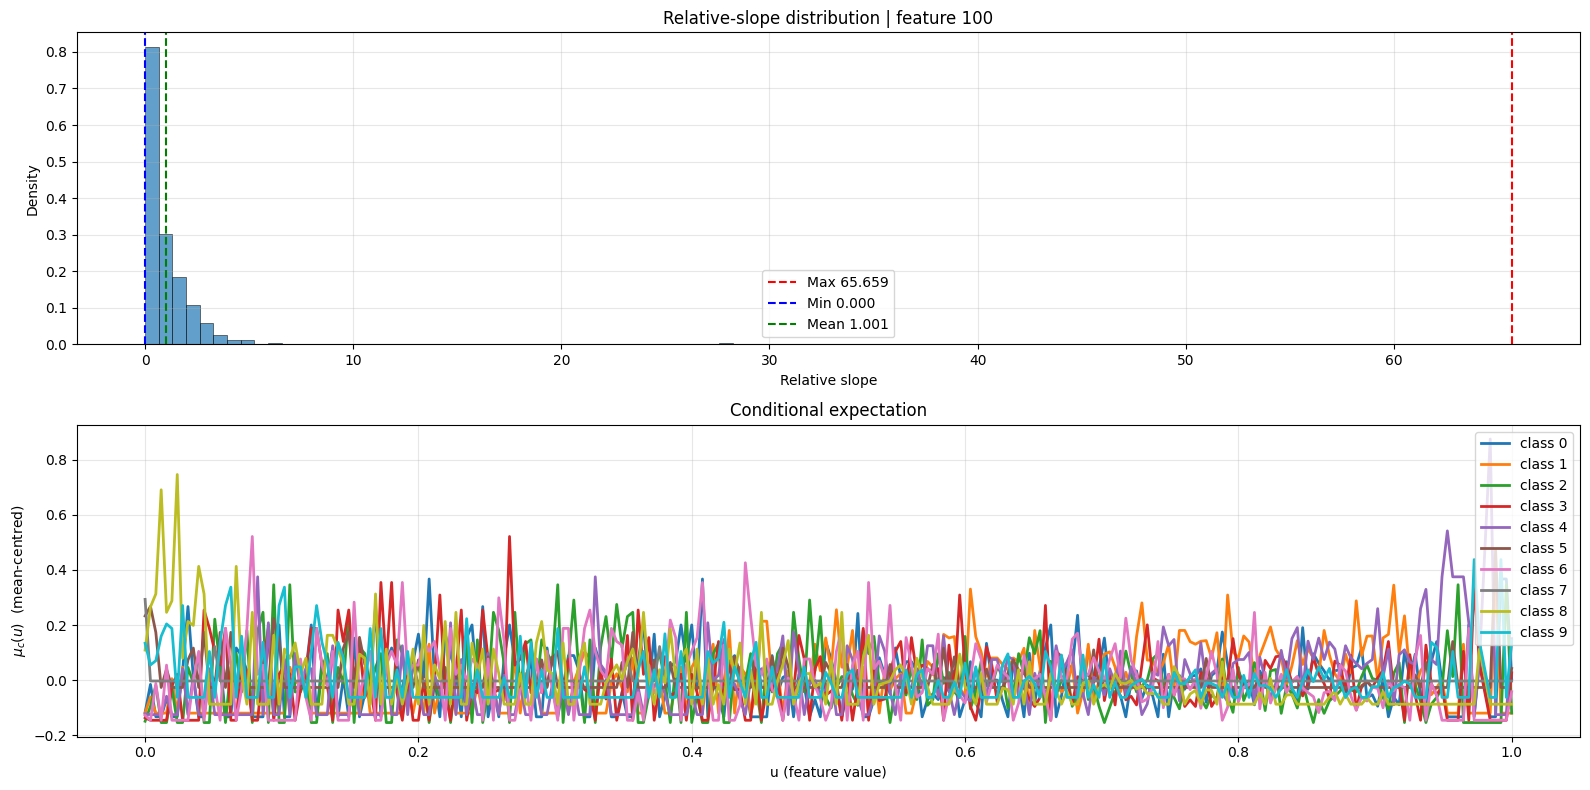

In [17]:
import matplotlib.pyplot as plt

# "CIFAR-10"
# "CIFAR-100
# "MNIST", download_and_process_mnist),
# "Fashion-MNIST"
# "Olivetti Faces"
fig = plot_dataset_feature(all_results,
                           dataset_name="Fashion-MNIST",
                           feature_idx=100,
                           bins=100,
                           figsize=(16,8))

plt.show()